# Bottom-Up Proteomics Processing

In-house, Perseus-like processing of bottom-up proteomics data exported from Excel.

Pipeline: **ingest → map gene symbols → group biological replicates into conditions → average →
compare conditions (fold change + statistics) → filter → visualize (volcano, heatmap) → PCA →
annotate (subcellular localization + function) → GO enrichment → compare across data sets.**

All logic lives in the reusable `ms_processing` package, so a future GUI/web app can call the
exact same functions. Each config variable below maps directly to a field a GUI form would collect.

## 1. Configuration

These are the inputs a user provides at upload time:
- **Experiment type** — ABPP, AP-MS, whole proteome, ... (`ms_processing.EXPERIMENT_TYPES`).
- **Plex** — 6, 10, 16 (standard) or any custom integer; this is how many data columns to expect.
- **Data start column** — defaults to `Z`; columns before it are annotation/metadata.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

# Make the package importable when running from the notebooks/ directory.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ms_processing as msp

# --- User inputs (GUI form fields) ---------------------------------------
DATA_FILE = REPO_ROOT / "sample_data" / "sample_dataset.xlsx"
EXPERIMENT_TYPE = "ABPP"   # see msp.EXPERIMENT_TYPES
PLEX = 6                    # 6 / 10 / 16, or any custom integer
DATA_START_COLUMN = "Z"    # quantitative data begins here

print("Available experiment types:", [e.name for e in msp.EXPERIMENT_TYPES.values()])
print("Standard plexes:", msp.STANDARD_PLEXES)
print("Gene-symbol column:", msp.DEFAULT_GENE_COLUMN)

Available experiment types: ['ABPP', 'AP-MS', 'Whole proteome']
Standard plexes: (6, 10, 16)
Gene-symbol column: Gene Symbol


## 2. Load the Excel file

First row = header, each subsequent row = one identified protein. Columns before `Z` are
annotation/metadata; `Z` onward (width = plex) are the quantitative data columns (one per
biological replicate).

In [2]:
dataset = msp.load_dataset(
    DATA_FILE,
    experiment_type=EXPERIMENT_TYPE,
    plex=PLEX,
    data_start_column=DATA_START_COLUMN,
)

summary = dataset.describe()
print("Experiment type :", summary["experiment_type"])
print("Plex            :", summary["plex"])
print("Proteins (rows) :", summary["n_proteins"])
print("Annotation cols :", summary["n_annotation_columns"])
print("Data col range  :", summary["data_column_range"])
print("Data columns    :", summary["data_columns"])

Experiment type : ABPP
Plex            : 6
Proteins (rows) : 200
Annotation cols : 25
Data col range  : Z-AE
Data columns    : ['Treatment_1', 'Treatment_2', 'Treatment_3', 'Mock_1', 'Mock_2', 'Mock_3']


In [3]:
dataset.annotations.head()

,Accession,Gene Symbol,Description,# Unique Peptides,Filler_4,Filler_5,Filler_6,Filler_7,Filler_8,Filler_9,...,Filler_15,Filler_16,Filler_17,Filler_18,Filler_19,Filler_20,Filler_21,Filler_22,Filler_23,Filler_24
0,P00000,GENE0,Example protein,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P00001,GENE1,Example protein,19,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P00002,GENE2,Example protein,16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P00003,NaN,Example protein,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P00004,GENE4,Example protein,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2b. Map gene symbols

The pipeline keys proteins on the **`Gene Symbol`** column. Where a row's gene symbol is blank,
its **`Accession`** (UniProt) is looked up and the gene name UniProt reports is filled in.

> Requires internet access to `rest.uniprot.org`; degrades gracefully here (synthetic accessions
> won't resolve). In your deployment this fills the blanks from real accessions.

In [4]:
gene_col = msp.DEFAULT_GENE_COLUMN
n_blank_before = dataset.raw[gene_col].astype(str).str.strip().isin(["", "nan"]).sum()
print(f"Rows missing a gene symbol before mapping: {n_blank_before}")

try:
    dataset.raw = msp.fill_gene_symbols(dataset.raw, gene_col=gene_col, accession_col="Accession")
    n_blank_after = dataset.raw[gene_col].astype(str).str.strip().isin(["", "nan"]).sum()
    print(f"Rows missing a gene symbol after mapping:  {n_blank_after}")
except msp.AnnotationServiceError as exc:
    print("Gene-symbol mapping unavailable in this environment:\n  ", exc)
    print("\nIn a deployment with internet access, blanks are filled from the UniProt accession.")

Rows missing a gene symbol before mapping: 0
Gene-symbol mapping unavailable in this environment:
   UniProt request failed: 403 Client Error: Forbidden for url: https://rest.uniprot.org/uniprotkb/accessions?accessions=P00003%2CP00017%2CP00042&fields=accession%2Cid%2Cprotein_name%2Cgene_names%2Ccc_function%2Ccc_subcellular_location&format=json

In a deployment with internet access, blanks are filled from the UniProt accession.


In [5]:
# Preview the quantitative data columns (one per biological replicate).
dataset.data.head()

,Treatment_1,Treatment_2,Treatment_3,Mock_1,Mock_2,Mock_3
0,57874.657260,55877.738249,65661.610544,35298.846224,38018.332380,27616.108752
1,9355.505450,7117.144141,8641.705572,7073.952352,10730.172846,7705.720587
2,19554.094446,18516.486575,17832.578741,15999.155231,17878.467655,15212.301519
3,64160.888270,92365.244499,77844.552469,82011.214193,88551.818051,59075.287843
4,17558.794790,13846.863086,13215.081191,15087.466657,16873.305333,16913.655539


## 3. Assign replicate columns to conditions

Each data column is a separate biological replicate. Group the replicates belonging to the same
experimental condition. In a GUI this is a form; here it is `{condition_name: [replicate_column, ...]}`.

In [6]:
condition_map = msp.ConditionMap.from_mapping({
    "Treatment": ["Treatment_1", "Treatment_2", "Treatment_3"],
    "Mock":      ["Mock_1", "Mock_2", "Mock_3"],
})
condition_map.validate(dataset)

for cond in condition_map:
    print(f"{cond.name:>12}: {cond.n_replicates} replicates -> {list(cond.replicate_columns)}")
print("\nUnassigned data columns:", condition_map.unassigned_columns(dataset) or "(none)")

   Treatment: 3 replicates -> ['Treatment_1', 'Treatment_2', 'Treatment_3']
        Mock: 3 replicates -> ['Mock_1', 'Mock_2', 'Mock_3']

Unassigned data columns: (none)


## 4. Average protein abundance per condition

In [7]:
means = msp.condition_means(dataset, condition_map)
means[["Accession", "Gene Symbol", *condition_map.names]].head()

,Accession,Gene Symbol,Treatment,Mock
0,P00000,GENE0,59804.668684,33644.429119
1,P00001,GENE1,8371.451721,8503.281929
2,P00002,GENE2,18634.386587,16363.308135
3,P00003,NaN,78123.561746,76546.106696
4,P00004,GENE4,14873.579689,16291.475843


## 5. Compare two conditions

Pick numerator vs denominator (e.g. Treatment vs Mock): fold change, log2(fold change), two-sided
independent t-test p-value, adjusted p-value / FDR (selectable correction), and −log10(p-value).

In [8]:
for key, label in msp.CORRECTION_METHODS.items():
    print(f"  {key:<11} {label}")
print("\nDefault:", msp.DEFAULT_CORRECTION)

  fdr_bh      Benjamini-Hochberg (FDR)
  fdr_by      Benjamini-Yekutieli (FDR)
  bonferroni  Bonferroni
  holm        Holm-Bonferroni
  sidak       Sidak

Default: fdr_bh


In [9]:
NUMERATOR = "Treatment"
DENOMINATOR = "Mock"
CORRECTION = "fdr_bh"   # Benjamini-Hochberg; change to any key above
EQUAL_VAR = True         # True = Student's t-test, False = Welch's

results = msp.compare_conditions(
    dataset, condition_map,
    numerator=NUMERATOR, denominator=DENOMINATOR,
    correction=CORRECTION, equal_var=EQUAL_VAR,
)

stat_cols = [
    f"mean_{NUMERATOR}", f"mean_{DENOMINATOR}",
    "fold_change", "log2_fold_change", "p_value", "adj_p_value", "neg_log10_p_value",
]
print("Comparison:", results.attrs["comparison"], "| correction:", results.attrs["correction"])
results[["Accession", "Gene Symbol", *stat_cols]].head(10)

Comparison: Treatment vs Mock | correction: fdr_bh


,Accession,Gene Symbol,mean_Treatment,mean_Mock,fold_change,log2_fold_change,p_value,adj_p_value,neg_log10_p_value
0,P00000,GENE0,59804.668684,33644.429119,1.777550,0.829890,0.003734,0.018214,2.427835
1,P00001,GENE1,8371.451721,8503.281929,0.984497,-0.022542,0.924524,0.966132,0.034082
2,P00002,GENE2,18634.386587,16363.308135,1.138791,0.187503,0.072250,0.203521,1.141163
3,P00003,NaN,78123.561746,76546.106696,1.020608,0.029429,0.902493,0.966001,0.044556
4,P00004,GENE4,14873.579689,16291.475843,0.912967,-0.131365,0.393078,0.672205,0.405521
5,P00005,GENE5,42085.317846,53263.203770,0.790139,-0.339822,0.041865,0.135049,1.378147
6,P00006,GENE6,8088.622716,7857.277676,1.029443,0.041865,0.874668,0.955921,0.058157
7,P00007,GENE7,15780.248684,18905.900121,0.834673,-0.260717,0.427265,0.703044,0.369303
8,P00008,GENE8,9259.803361,7507.209556,1.233455,0.302705,0.322324,0.634213,0.491707
9,P00009,GENE9,17629.035734,15255.934402,1.155553,0.208583,0.295368,0.621828,0.529636


## 6. Filter the results

Apply any combination of thresholds (combine with AND; leave any as `None` to skip).

In [10]:
filtered = msp.filter_results(
    results,
    max_fdr=0.05,            # keep FDR <= 0.05
    min_abs_log2fc=1.0,      # keep |log2 FC| >= 1 (>= 2-fold change)
    min_unique_peptides=2,   # keep proteins with >= 2 unique peptides
)
print(f"Proteins before filtering: {len(results)}")
print(f"Proteins after filtering : {len(filtered)}")
filtered[["Accession", "Gene Symbol", "# Unique Peptides", *stat_cols]].head(10)

Proteins before filtering: 200
Proteins after filtering : 50


,Accession,Gene Symbol,# Unique Peptides,mean_Treatment,mean_Mock,fold_change,log2_fold_change,p_value,adj_p_value,neg_log10_p_value
13,P00013,GENE13,19,11308.047559,29331.908299,0.385520,-1.375121,0.000244,0.003247,3.613474
14,P00014,GENE14,18,33975.848194,11477.875625,2.960116,1.565654,0.006163,0.025153,2.210242
15,P00015,GENE15,19,16779.147171,5079.859030,3.303073,1.723809,0.000016,0.000819,4.785932
20,P00020,GENE20,13,375753.894881,112259.742502,3.347183,1.742947,0.000632,0.005267,3.199261
25,P00025,GENE25,16,166479.228484,76434.889587,2.178053,1.123039,0.005609,0.023866,2.251145
30,P00030,GENE30,11,31720.274375,11274.318178,2.813498,1.492365,0.000911,0.006359,3.040461
32,P00032,GENE32,3,50932.670465,13075.767290,3.895196,1.961696,0.000922,0.006359,3.035236
33,P00033,GENE33,14,17640.650921,5341.054595,3.302840,1.723707,0.000597,0.005256,3.223911
37,P00037,GENE37,20,22917.625408,9646.181728,2.375824,1.248428,0.002302,0.012443,2.637915
39,P00039,GENE39,16,16157.652245,52559.268412,0.307418,-1.701728,0.000047,0.001159,4.327583


## 7. Volcano plot

log2(fold change) vs −log10(p-value). Points beyond the cutoffs are colored up (red) / down
(blue). The most significant **and** largest fold-change hits are labelled, with labels repelled
so they don't overlap (via `adjustText`). Set `use_adjusted=True` to plot FDR instead of raw p.

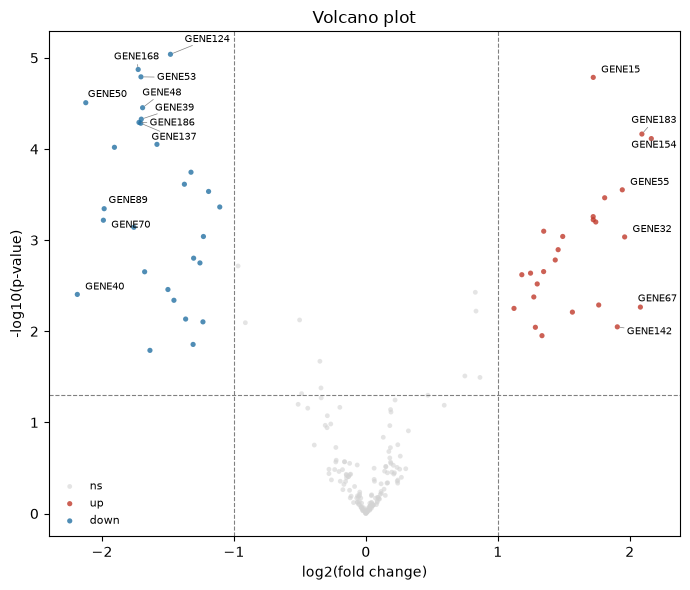

In [11]:
ax = msp.volcano_plot(
    results,
    fc_threshold=1.0,      # |log2FC| cutoff (dashed vertical lines)
    p_threshold=0.05,      # p-value cutoff (dashed horizontal line)
    use_adjusted=False,    # True -> use adjusted p-value / FDR
    label_col="Gene Symbol", n_labels=10,
)
plt.tight_layout(); plt.show()

## 8. Heatmap

Abundance across replicates for the significant proteins, z-scored per protein so relative
patterns stand out. `cluster=True` uses `seaborn.clustermap` to cluster proteins and samples.

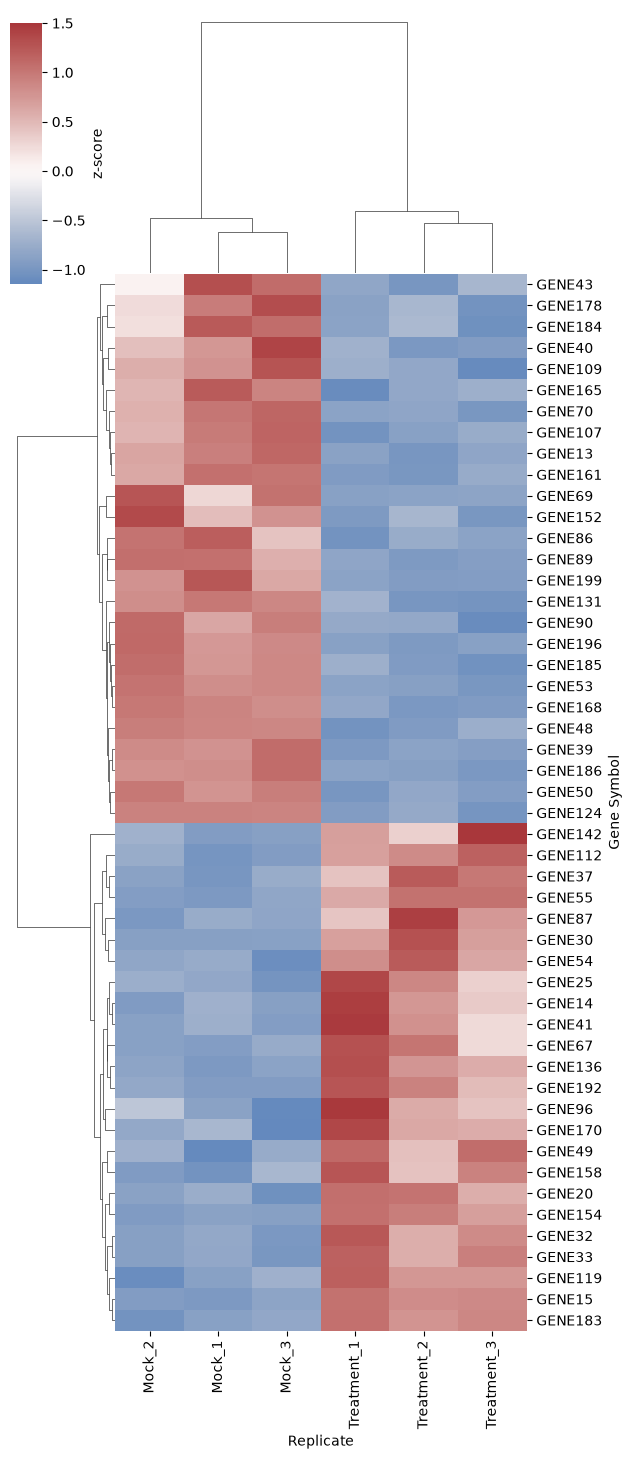

In [12]:
grid = msp.abundance_heatmap(
    dataset, condition_map,
    proteins=filtered.index,   # the significant hits from step 6
    label_col="Gene Symbol",
    zscore_rows=True,
    cluster=True,
    max_proteins=50,
)
plt.show()

## 9. PCA (sample QC / structure)

Principal component analysis treats each **replicate (data column) as a sample** and each
**protein as a feature**, to check whether replicates of the same condition cluster and whether
conditions separate. Proteins are standardized by default; set `log_transform=True` if your
abundances are raw intensities rather than already log-scaled.

Explained variance: ['40.7%', '18.1%']


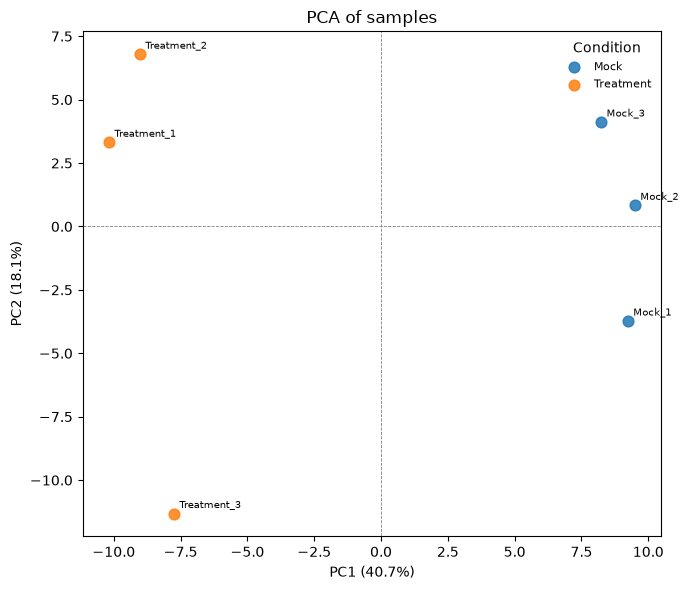

In [13]:
pca = msp.run_pca(
    dataset, condition_map,
    n_components=2,
    scale=True,            # standardize proteins so abundant ones don't dominate
    log_transform=False,   # True if abundances are raw (not log) intensities
)
print("Explained variance:", [f"{v:.1%}" for v in pca.explained_variance_ratio])

msp.pca_plot(pca, pc_x=1, pc_y=2, label_samples=True)
plt.tight_layout(); plt.show()

## 10. Subcellular localization & protein function (UniProt)

Looks up each protein's accession against the **UniProt REST API** and adds columns for protein
name, **subcellular localization**, and a snapshot of the protein **function**.

> Requires outbound internet access to `rest.uniprot.org`. The cell degrades gracefully if the
> service is unreachable. Note: the bundled sample data uses synthetic accessions (`P00000`…),
> so a live run resolves to empty fields — point it at real UniProt accessions to see results.

In [14]:
try:
    annotated = msp.annotate_results(filtered, accession_col="Accession")
    display(annotated[["Accession", "Gene Symbol", "UniProt_Protein_Name",
                       "Subcellular_Location", "Function"]].head(10))
except msp.AnnotationServiceError as exc:
    print("UniProt annotation unavailable in this environment:\n  ", exc)
    print("\nIn a deployment with internet access this adds Subcellular_Location and Function columns.")

UniProt annotation unavailable in this environment:
   UniProt request failed: 403 Client Error: Forbidden for url: https://rest.uniprot.org/uniprotkb/accessions?accessions=P00013%2CP00014%2CP00015%2CP00020%2CP00025%2CP00030%2CP00032%2CP00033%2CP00037%2CP00039%2CP00040%2CP00041%2CP00043%2CP00048%2CP00049%2CP00050%2CP00053%2CP00054%2CP00055%2CP00067%2CP00069%2CP00070%2CP00086%2CP00087%2CP00089%2CP00090%2CP00096%2CP00107%2CP00109%2CP00112%2CP00119%2CP00124%2CP00131%2CP00136%2CP00142%2CP00152%2CP00154%2CP00158%2CP00161%2CP00165%2CP00168%2CP00170%2CP00178%2CP00183%2CP00184%2CP00185%2CP00186%2CP00192%2CP00196%2CP00199&fields=accession%2Cid%2Cprotein_name%2Cgene_names%2Ccc_function%2Ccc_subcellular_location&format=json

In a deployment with internet access this adds Subcellular_Location and Function columns.


## 11. GO term enrichment (Enrichr)

Runs an over-representation test on the significant genes against a GO gene-set library using
the **Enrichr API**, returning enriched terms with p-values and BH-adjusted p-values, plus a
bar plot of the top terms.

> Requires outbound internet access to `maayanlab.cloud`. Degrades gracefully if unreachable.
> The synthetic `GENE…` symbols won't enrich — use real gene symbols for meaningful results.

In [15]:
print("GO libraries:", msp.GO_LIBRARIES)

genes = filtered["Gene Symbol"].dropna().astype(str).tolist()
try:
    enrichment = msp.enrich_genes(genes, library=msp.GO_LIBRARIES["BP"])
    display(enrichment[["Term", "P_value", "Adj_P_value", "N_overlap"]].head(10))
    msp.enrichment_barplot(enrichment, top_n=15)
    plt.tight_layout(); plt.show()
except msp.EnrichmentServiceError as exc:
    print("Enrichr enrichment unavailable in this environment:\n  ", exc)
    print("\nIn a deployment with internet access this returns enriched GO terms + a bar plot.")

GO libraries: {'BP': 'GO_Biological_Process_2023', 'MF': 'GO_Molecular_Function_2023', 'CC': 'GO_Cellular_Component_2023'}


Enrichr enrichment unavailable in this environment:
   Enrichr request failed: 403 Client Error: Forbidden for url: https://maayanlab.cloud/Enrichr/addList

In a deployment with internet access this returns enriched GO terms + a bar plot.


## 12. Compare across data sets (one or more Excel files)

Provide the path to **one or more** Excel files and choose how their columns line up:

- **Identical columns** — pass a list of paths plus a shared experiment type + plex. The same
  configuration (and the same condition map) is applied to every file.
- **Adjusted per file** — pass a list of `msp.DatasetSpec`, each with its own experiment type,
  plex, and data-start column; supply a per-file `{name: ConditionMap}` to `compare_across_datasets`.

Then align the results by protein and compare: a side-by-side metric table, the overlap of
significant hits, the log2FC correlation, and a scatter of log2FC in data set A vs B.

In [16]:
# --- User input: the file path(s) -----------------------------------------
FILE_PATHS = [
    REPO_ROOT / "sample_data" / "sample_dataset.xlsx",
    REPO_ROOT / "sample_data" / "sample_dataset_2.xlsx",
]
COLUMNS_IDENTICAL = True   # set False to configure each file separately (see below)

if COLUMNS_IDENTICAL:
    # Same experiment type / plex / layout for every file.
    datasets = msp.load_datasets(FILE_PATHS, EXPERIMENT_TYPE, PLEX, names=["DatasetA", "DatasetB"])
    condition_maps = condition_map               # one shared map
else:
    # Per-file configuration (edit experiment_type / plex / data_start_column as needed).
    specs = [
        msp.DatasetSpec(FILE_PATHS[0], "ABPP",  6, name="DatasetA", data_start_column="Z"),
        msp.DatasetSpec(FILE_PATHS[1], "AP-MS", 6, name="DatasetB", data_start_column="Z"),
    ]
    datasets = msp.load_datasets(specs)
    # Per-file condition maps keyed by dataset name.
    condition_maps = {
        "DatasetA": condition_map,
        "DatasetB": condition_map,
    }

print("Loaded:", {name: ds.describe()["data_column_range"] for name, ds in datasets.items()})

Loaded: {'DatasetA': 'Z-AE', 'DatasetB': 'Z-AE'}


In [17]:
# Run the same comparison on each data set, then align by protein.
results_by_dataset = msp.compare_across_datasets(datasets, condition_maps, "Treatment", "Mock")

aligned = msp.align_results(results_by_dataset, value_cols=("log2_fold_change", "adj_p_value"))
aligned.head()

,Accession,Gene Symbol,log2_fold_change__DatasetA,adj_p_value__DatasetA,log2_fold_change__DatasetB,adj_p_value__DatasetB
0,P00000,GENE0,0.829890,0.018214,1.376253,0.057512
1,P00001,GENE1,-0.022542,0.966132,0.649665,0.039426
2,P00002,GENE2,0.187503,0.203521,-0.052138,0.902131
3,P00003,NaN,0.029429,0.966001,0.106906,0.714844
4,P00004,GENE4,-0.131365,0.672205,-0.235570,0.336434


Significant per data set: {'DatasetA': 52, 'DatasetB': 48}
Shared: 42 | Union: 58
log2FC Pearson correlation: 0.872


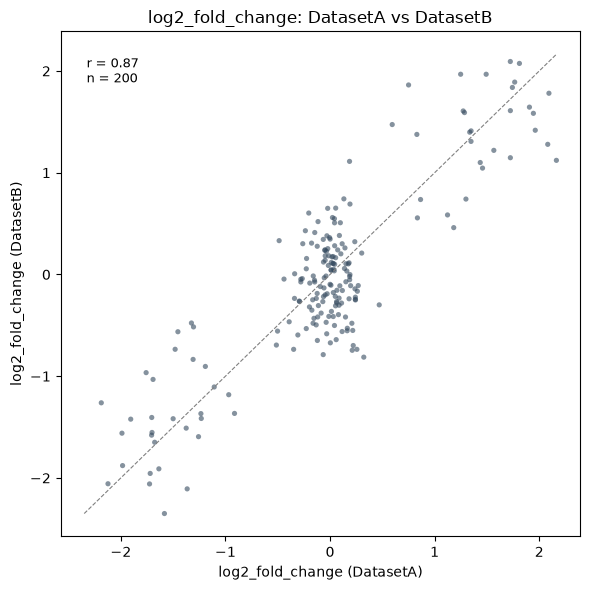

In [18]:
# Overlap of significant hits (same significance rule applied to each data set).
sig = msp.significant_sets(results_by_dataset, max_fdr=0.05, min_abs_log2fc=1.0)
summary = msp.overlap_summary(sig)
print("Significant per data set:", summary["per_dataset_counts"])
print("Shared:", summary["n_shared"], "| Union:", summary["n_union"])

r = msp.correlate_metric(aligned, "DatasetA", "DatasetB", metric="log2_fold_change")
print(f"log2FC Pearson correlation: {r:.3f}")

msp.compare_scatter(aligned, "DatasetA", "DatasetB", metric="log2_fold_change")
plt.tight_layout(); plt.show()

## Mapping to a future GUI

| Notebook step | Package call | GUI form field(s) |
|---|---|---|
| 1–2 Upload & load | `msp.load_dataset(path, experiment_type, plex, data_start_column)` | file upload, experiment dropdown, plex selector |
| 2b Gene mapping | `msp.fill_gene_symbols(df, gene_col, accession_col)` | (automatic, online) |
| 3 Conditions | `msp.ConditionMap.from_mapping({...})` | assign replicate columns to conditions |
| 4 Averages | `msp.condition_means(dataset, condition_map)` | (automatic) |
| 5 Compare | `msp.compare_conditions(..., numerator, denominator, correction, equal_var)` | comparison picker, correction, t-test type |
| 6 Filter | `msp.filter_results(results, max_pvalue, max_fdr, min_abs_log2fc, min_unique_peptides)` | filter threshold inputs |
| 7 Volcano | `msp.volcano_plot(results, fc_threshold, p_threshold, use_adjusted, n_labels)` | cutoff sliders, # labels |
| 8 Heatmap | `msp.abundance_heatmap(dataset, condition_map, proteins, zscore_rows, cluster)` | protein selection, z-score/cluster toggles |
| 9 PCA | `msp.run_pca(dataset, condition_map, scale, log_transform)` + `msp.pca_plot(pca)` | scale/log toggles, component pickers |
| 10 Annotation | `msp.annotate_results(results, accession_col)` | (automatic, online) |
| 11 Enrichment | `msp.enrich_genes(genes, library)` | GO library selector |
| 12 Cross-data-set | `msp.load_datasets(...)`, `msp.compare_across_datasets(...)`, `msp.align_results(...)`, `msp.compare_scatter(...)` | multi-file upload, identical-vs-per-file toggle, metric picker |

Future iterations: remote file storage, the web/GUI front end, and normalization/imputation.